In [1]:
from sklearn.datasets import load_iris
# load the data and let's look at it
iris = load_iris(as_frame=True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [2]:

iris.data.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [3]:
iris.target.head(5)
# note that the targets are not shuffled (all of type 0)

,target
0,0
1,0
2,0
3,0
4,0


In [4]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


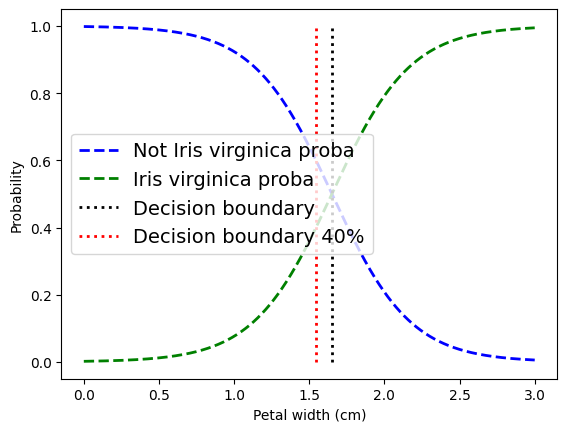

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

X=iris.data[["petal width (cm)"]] #the X data
y= iris.target_names[iris.target] == "virginica" #we want to detect the Iris virginica
X_train , X_test, y_train, y_test = train_test_split(X,y, random_state=42)

log_reg=LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

X_new = np.linspace(0,3,1000).reshape(-1,1) # reshape to get a column vector
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:,1]>=0.5][0,0]
decision_boundary04 = X_new[y_proba[:,1]>=0.4][0,0]

plt.plot(X_new, y_proba[:,0], "b--", linewidth=2, label="Not Iris virginica proba")
plt.plot(X_new, y_proba[:,1], "g--", linewidth=2, label="Iris virginica proba")
plt.plot([decision_boundary, decision_boundary], [0,1], "k:", linewidth=2, label="Decision boundary")
plt.plot([decision_boundary04, decision_boundary04], [0,1], "r:", linewidth=2, label="Decision boundary 40%")
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.legend(loc="center left", fontsize=14)
plt.show()




In [10]:
decision_boundary

np.float64(1.6516516516516517)

In [11]:
log_reg.predict([[1.7], [1.5]])
# petal width above the decision boundary is predicted as iris virginica, below as not iris virginica

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([ True, False])